In [1]:
# ==============================================================================
# Chandeleur Islands — WIS Gulf of Mexico wave climate
# csherwood@usgs.gov, 2026-06-18, generated with Claude Sonnet 4.6
#
# Station ST73141  (Gulf of Mexico, near Chandeleur Islands)
# WIS GoM hindcast: 1980–2023 (hourly)
# Data downloaded from ERDC THREDDS:
#   https://chldata.erdc.dren.mil/thredds/fileServer/wis/GulfOfMexico/
#                ST{STATION_ID}/{year}/WIS-ocean_waves_ST{STATION_ID}_{year}{mo:02d}.nc
#
# Derived quantities
#   R2%  : Stockdon et al. (2006) 2% runup exceedance
#   P    : Deep-water wave power (energy flux), Holthuijsen (2007)
#   Omega: Non-dimensional settling velocity = Hs*Tp / ws
#          (Dean 1973; Wright & Short 1984)
# ==============================================================================
import os, warnings, urllib.request
import netCDF4 as nc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from scipy import stats as spstats
warnings.filterwarnings('ignore')

# ── Station and cache ─────────────────────────────────────────────────────────
STATION_ID = '73141'
CACHE_DIR  = r'F:\crs\proj\2026_Chandeleur_fluxes\WIS_cache'
FIRST_YEAR = 1980
LAST_YEAR  = 2023

# WIS THREDDS file server base URL (Gulf of Mexico)
WIS_BASE = ('https://chldata.erdc.dren.mil/thredds/fileServer/'
            'wis/GulfOfMexico/ST{sid}/{yr}/')
WIS_FILE = 'WIS-ocean_waves_ST{sid}_{yr}{mo:02d}.nc'

os.makedirs(CACHE_DIR, exist_ok=True)

# ── Physical constants ────────────────────────────────────────────────────────
G   = 9.81        # m/s²
RHO = 1025.0      # kg/m³  (sea water)

# ── Stockdon runup (beach-face slope) ────────────────────────────────────────
# Chandeleur Islands are low-slope dissipative barriers; 0.02 is a conservative
# starting point (adjust after site-specific survey data are available).
BETA = 0.02

# ── Sediment settling velocity ────────────────────────────────────────────────
# Chandeleur Islands: D50 ≈ 0.20–0.30 mm (fine to medium sand; USGS cores).
# ws computed via Ferguson & Church (2004), eqn. (1):
#   ws = R*g*D50^2 / (C1*nu + sqrt(0.75*C2*R*g*D50^3))
#   R=1.65, C1=18, C2=1.0 (natural grains), nu=1e-6 m²/s at 20°C
# Reference: Ferguson, R.I. & Church, M. (2004). A simple universal equation
#   for grain settling velocity. J. Sediment. Res. 74(6), 933-937.
D50  = 0.00025   # m (0.25 mm — adjust as needed)
NU   = 1.0e-6    # kinematic viscosity, m²/s (20°C seawater ≈ ok for GoM)
R    = 1.65      # submerged specific gravity (quartz)
C1, C2 = 18.0, 1.0
WS   = R * G * D50**2 / (C1 * NU + np.sqrt(0.75 * C2 * R * G * D50**3))
print(f'Settling velocity ws = {WS:.4f} m/s  (D50 = {D50*1000:.2f} mm)')

Settling velocity ws = 0.0318 m/s  (D50 = 0.25 mm)


In [2]:
# ==============================================================================
# CELL 2 — Download missing monthly NetCDF files to local cache
#
# Files are ~100–300 kB each; 44 years × 12 months ≈ 528 files.
# Already-cached files are skipped; failed downloads are logged.
# ==============================================================================

failed = []
downloaded = 0
skipped = 0

for yr in range(FIRST_YEAR, LAST_YEAR + 1):
    for mo in range(1, 13):
        fname  = WIS_FILE.format(sid=STATION_ID, yr=yr, mo=mo)
        flocal = os.path.join(CACHE_DIR, fname)
        if os.path.exists(flocal):
            skipped += 1
            continue
        url = (WIS_BASE.format(sid=STATION_ID, yr=yr) + fname)
        try:
            urllib.request.urlretrieve(url, flocal)
            downloaded += 1
        except Exception as e:
            failed.append((yr, mo, str(e)))

print(f'Downloaded: {downloaded}   Skipped (cached): {skipped}   Failed: {len(failed)}')
if failed:
    for yr, mo, err in failed[:10]:
        print(f'  {yr}/{mo:02d}: {err}')

Downloaded: 528   Skipped (cached): 0   Failed: 0


In [3]:
# ==============================================================================
# CELL 3 — Load cached files into a single hourly DataFrame
#
# Variables: waveHs [m], waveTp [s], waveTm [s]
#   waveTm fallback: Tp / 1.28 (JONSWAP Tm01 approx.; Holthuijsen 2007)
#
# Derived variables
#   L0   = g Tp² / (2π)          deep-water wavelength (m)
#   R2   = Stockdon (2006) R2% runup (m)
#   Te   = Tm / 0.90             energy period (JONSWAP; Tucker & Pitt 2001)
#   P    = (ρ g²)/(64π) Hs² Te   deep-water wave power (W/m → kW/m)
#   Omega = Hs * Tp / ws          non-dimensional settling velocity
#           (Dean 1973, J. Waterw. Port Coast. Ocean Div. 99(WW3):631-640;
#            Wright & Short 1984, Mar. Geol. 56:93-118)
# ==============================================================================

records = []
missing_files = 0

for yr in range(FIRST_YEAR, LAST_YEAR + 1):
    for mo in range(1, 13):
        fpath = os.path.join(CACHE_DIR,
                    WIS_FILE.format(sid=STATION_ID, yr=yr, mo=mo))
        if not os.path.exists(fpath):
            missing_files += 1
            continue
        with nc.Dataset(fpath) as ds:
            tvar  = ds.variables['time']
            times = nc.num2date(tvar[:], tvar.units,
                                calendar=getattr(tvar, 'calendar', 'standard'))
            hs = ds.variables['waveHs'][:].filled(np.nan)
            tp = ds.variables['waveTp'][:].filled(np.nan)
            tm = (ds.variables['waveTm'][:].filled(np.nan)
                  if 'waveTm' in ds.variables else tp / 1.28)
        dts = pd.to_datetime([t.isoformat() for t in times])
        records.append(pd.DataFrame({'Hs': hs, 'Tp': tp, 'Tm': tm}, index=dts))

df = pd.concat(records).sort_index()
df = df[~df.index.duplicated()]

# Stockdon (2006) R2%  [eq. 19]
# R2% = 1.1 * { 0.35β√(Hs L0) + √[Hs L0 (0.563β² + 0.004)] / 2 }
L0        = G * df['Tp']**2 / (2 * np.pi)
df['R2']  = 1.1 * (0.35 * BETA * np.sqrt(df['Hs'] * L0)
            + np.sqrt(df['Hs'] * L0 * (0.563 * BETA**2 + 0.004)) / 2)

# Wave power (kW/m)  [Holthuijsen 2007, eq. 5.4.17]
Te          = df['Tm'] / 0.90
df['P_kW']  = (RHO * G**2) / (64 * np.pi) * df['Hs']**2 * Te / 1000

# Non-dimensional settling velocity Ω  [Dean 1973; Wright & Short 1984]
df['Omega'] = df['Hs'] * df['Tp'] / WS

df['month'] = df.index.month

# Drop years with < 8000 hours of valid Hs data (< ~91% complete)
year_counts = df.groupby(df.index.year)['Hs'].count()
good_years  = year_counts[year_counts >= 8000].index
df = df[df.index.year.isin(good_years)]

print(f'Missing files: {missing_files}')
print(f'Record: {df.index[0].date()} → {df.index[-1].date()}  '
      f'({len(df):,} hourly records)')
print(f'Dropped years (< 8000 h): {sorted(set(range(FIRST_YEAR,LAST_YEAR+1)) - set(good_years))}')
print(df[['Hs','Tp','Tm','R2','P_kW','Omega']].describe().round(3))

Missing files: 0
Record: 1980-01-01 → 2023-12-31  (385,703 hourly records)
Dropped years (< 8000 h): []
               Hs          Tp          Tm          R2        P_kW       Omega
count  385703.000  385703.000  385703.000  385703.000  385703.000  385703.000
mean        0.753       5.004       4.463       0.233       2.819     134.056
std         0.585       1.354       1.034       0.150      10.000     154.815
min         0.000       2.430       2.031       0.000       0.000       0.000
25%         0.344       4.117       3.773       0.129       0.239      43.694
50%         0.617       4.828       4.344       0.203       0.875      91.896
75%         1.031       5.758       5.023       0.302       2.734     175.684
max        10.531      16.719      14.430       2.870     811.359    5287.962


In [4]:
# ==============================================================================
# CELL 4 — Annual statistics table
#
# Compute mean, p25, median, p75, p95, p99, max for each year.
# Tracking the full percentile suite allows us to distinguish bulk shifts
# (all quantiles move together) from tail changes (only upper quantiles shift).
# ==============================================================================

def ann_stats(col):
    return df.groupby(df.index.year)[col].agg(
        mean   = 'mean',
        p25    = lambda x: x.quantile(0.25),
        median = 'median',
        p75    = lambda x: x.quantile(0.75),
        p95    = lambda x: x.quantile(0.95),
        p99    = lambda x: x.quantile(0.99),
        max    = 'max',
    ).dropna()

ann_Hs    = ann_stats('Hs')
ann_Tp    = ann_stats('Tp')
ann_R2    = ann_stats('R2')
ann_P     = ann_stats('P_kW')
ann_Omega = ann_stats('Omega')

print('── Annual Hs (m) ──')
print(ann_Hs.round(3).to_string())

── Annual Hs (m) ──
       mean    p25  median    p75    p95    p99     max
1980  0.725  0.352   0.617  0.969  1.773  2.570   3.141
1981  0.692  0.289   0.539  0.930  1.812  2.719   4.102
1982  0.815  0.391   0.672  1.141  1.930  2.781   3.438
1983  0.867  0.383   0.719  1.148  2.219  3.413   5.242
1984  0.759  0.320   0.648  1.047  1.812  2.353   3.367
1985  0.779  0.289   0.578  1.041  2.031  3.850   6.789
1986  0.657  0.320   0.547  0.852  1.633  2.367   3.812
1987  0.685  0.289   0.539  0.953  1.727  2.500   3.523
1988  0.758  0.312   0.633  1.078  1.773  2.719   5.727
1989  0.673  0.344   0.602  0.898  1.571  2.133   2.867
1990  0.651  0.297   0.547  0.891  1.649  2.172   2.992
1991  0.792  0.344   0.648  1.109  1.961  2.547   3.492
1992  0.662  0.289   0.523  0.906  1.594  2.398   4.148
1993  0.715  0.320   0.578  1.000  1.742  2.472   4.180
1994  0.718  0.344   0.594  0.953  1.727  2.542   3.570
1995  0.821  0.398   0.656  1.141  2.000  2.523   6.992
1996  0.817  0.367   0.648  

In [5]:
# ==============================================================================
# CELL 5 — Trend analysis functions
#
# Mann-Kendall non-parametric trend test + Sen's slope
#   Mann (1945), Econometrica 13:245; Kendall (1975), Griffin;
#   Sen (1968), JASA 63:1379.
#
# OLS linear regression with 95% CI and Durbin-Watson serial-correlation test.
# ==============================================================================

def mann_kendall(x):
    n = len(x)
    S = sum(np.sign(x[j] - x[i]) for i in range(n-1) for j in range(i+1, n))
    var_S = n*(n-1)*(2*n+5) / 18
    z = (S - np.sign(S)) / np.sqrt(var_S) if S != 0 else 0.0
    p = 2 * (1 - spstats.norm.cdf(abs(z)))
    tau = S / (0.5 * n * (n-1))
    slopes = [(x[j]-x[i])/(j-i) for i in range(n-1) for j in range(i+1, n)]
    sen_slope = np.median(slopes)
    sen_intercept = np.median(x - sen_slope * np.arange(n))
    return dict(S=S, z=z, p=p, tau=tau,
                sen_slope=sen_slope, sen_intercept=sen_intercept)

def ols_trend(y, years):
    xc = years - years.mean()
    slope, intercept_c, r, p, se = spstats.linregress(xc, y)
    n   = len(y)
    t95 = spstats.t.ppf(0.975, df=n-2)
    resid = y - (slope*xc + intercept_c)
    dw    = np.sum(np.diff(resid)**2) / np.sum(resid**2)
    return dict(slope=slope, r2=r**2, p=p, se=se, dw=dw,
                ci=t95*se, slope_per_decade=slope*10, ci_per_decade=t95*se*10)

# ── Run trends on all annual statistics ──────────────────────────────────────
all_trends = {}   # key: 'Hs_mean', 'Tp_p95', ...

header = (f"{'Variable':<16} {'MK p':>7} {'tau':>6} "
          f"{'Sen/yr':>9} {'Sen/dec':>9} {'OLS/dec':>9} "
          f"{'±CI':>8} {'OLS p':>7} {'DW':>5}")
print(header)
print('─' * len(header))

for label, ann_df, unit in [
        ('Hs',    ann_Hs,    'm'),
        ('Tp',    ann_Tp,    's'),
        ('R2',    ann_R2,    'm'),
        ('P_kW',  ann_P,     'kW/m'),
        ('Omega', ann_Omega, '-')]:
    print()
    for stat in ['mean','p25','median','p75','p95','p99','max']:
        y   = ann_df[stat].dropna().values
        yrs = ann_df[stat].dropna().index.values.astype(float)
        mk  = mann_kendall(y)
        ols = ols_trend(y, yrs)
        key = f'{label}_{stat}'
        all_trends[key] = {'mk': mk, 'ols': ols, 'y': y, 'yrs': yrs, 'unit': unit}
        sig = '*' if mk['p'] < 0.05 else ('~' if mk['p'] < 0.10 else ' ')
        print(f"  {key:<18} {mk['p']:>6.3f}{sig} {mk['tau']:>6.3f} "
              f"{mk['sen_slope']:>9.4f} "
              f"{mk['sen_slope']*10:>9.4f} "
              f"{ols['slope_per_decade']:>9.4f} "
              f"±{ols['ci_per_decade']:>6.4f} "
              f"{ols['p']:>7.3f} {ols['dw']:>5.2f}")

print('\n* p<0.05  ~ p<0.10  DW≈2 → no serial correlation')

Variable            MK p    tau    Sen/yr   Sen/dec   OLS/dec      ±CI   OLS p    DW
────────────────────────────────────────────────────────────────────────────────────

  Hs_mean             0.379   0.093    0.0007    0.0071    0.0052 ±0.0139   0.459  1.82
  Hs_p25              0.093~  0.177    0.0008    0.0078    0.0059 ±0.0085   0.171  1.74
  Hs_median           0.117   0.165    0.0010    0.0101    0.0093 ±0.0125   0.140  1.99
  Hs_p75              0.671   0.045    0.0003    0.0035    0.0061 ±0.0195   0.532  1.98
  Hs_p95              0.671  -0.045   -0.0009   -0.0088   -0.0120 ±0.0384   0.531  2.04
  Hs_p99              0.927   0.011    0.0004    0.0041   -0.0204 ±0.1103   0.711  2.49
  Hs_max              0.436   0.082    0.0110    0.1095    0.2520 ±0.5072   0.322  2.02

  Tp_mean             0.010*  0.271    0.0055    0.0555    0.0529 ±0.0383   0.008  1.60
  Tp_p25              0.053~  0.203    0.0032    0.0322    0.0282 ±0.0303   0.067  1.55
  Tp_median           0.004*  0.298 

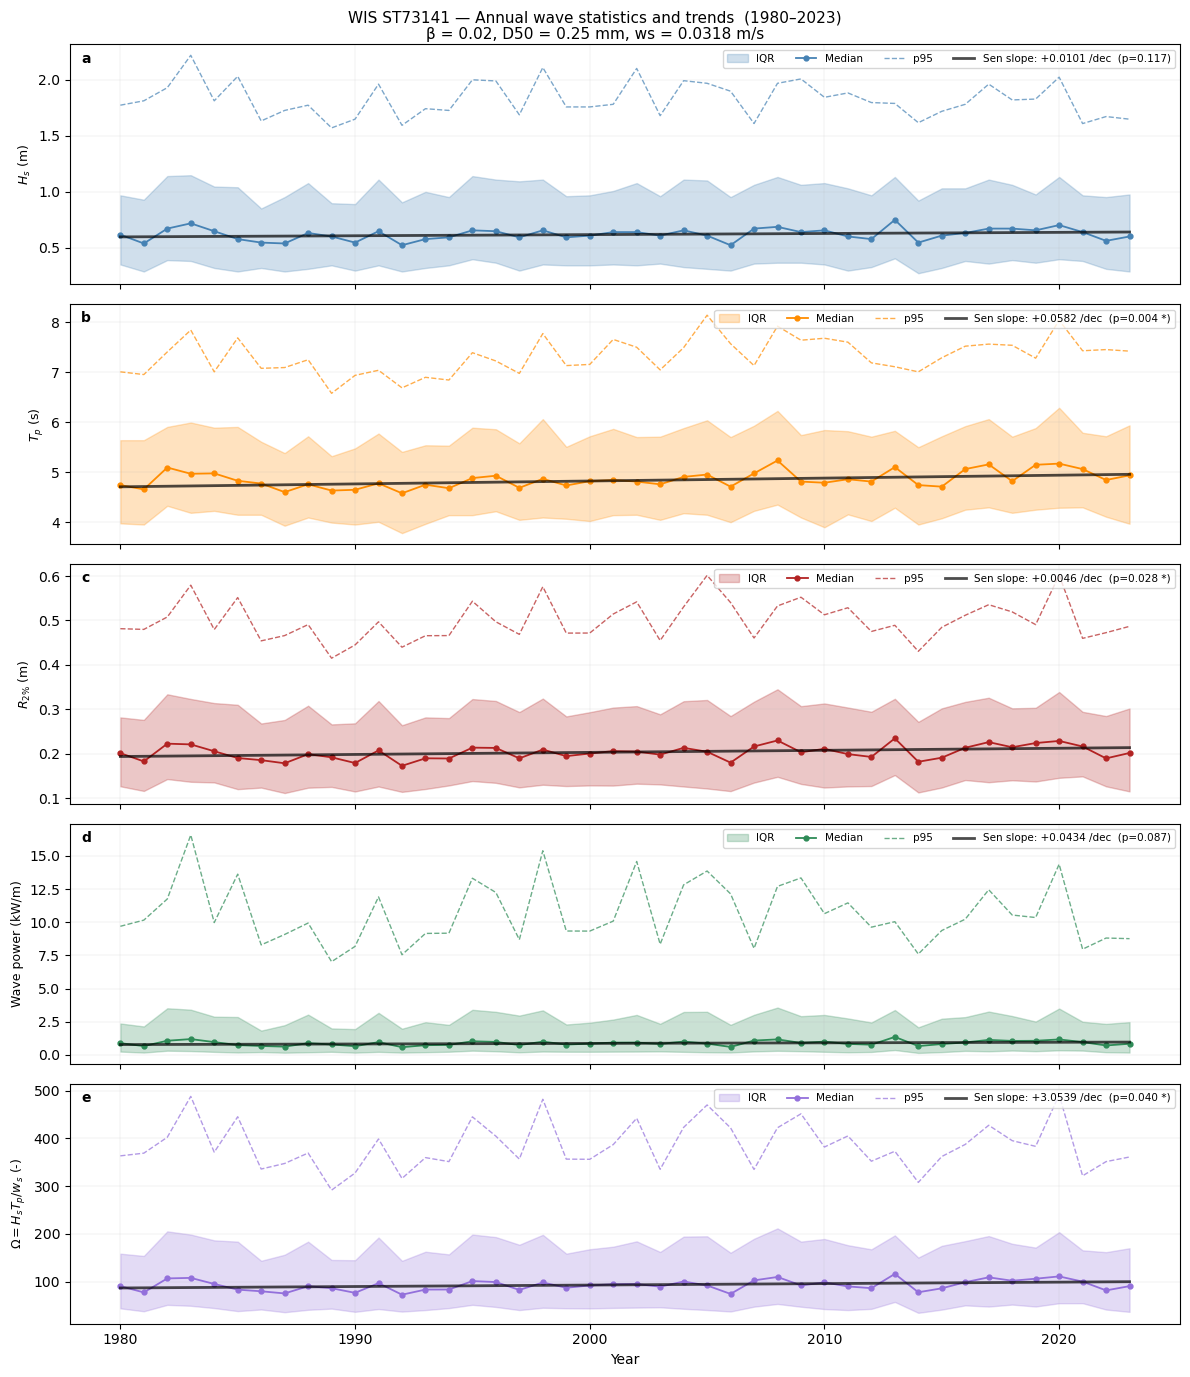

In [6]:
# ==============================================================================
# CELL 6 — Annual time series with trend lines (5-variable overview)
#
# Each panel shows annual median and p95; Sen's slope fitted to median.
# Panels labelled a–e in upper-left corner per figure convention.
# ==============================================================================

fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)
panel_cfg = [
    ('Hs',    'steelblue',     '$H_s$ (m)'),
    ('Tp',    'darkorange',    '$T_p$ (s)'),
    ('R2',    'firebrick',     '$R_{2\\%}$ (m)'),
    ('P_kW',  'seagreen',      'Wave power (kW/m)'),
    ('Omega', 'mediumpurple',  '$\\Omega = H_s T_p / w_s$ (-)'),
]
letters = 'abcde'

for ax, (var, col, ylabel), ltr, ann_df in zip(
        axes, panel_cfg, letters,
        [ann_Hs, ann_Tp, ann_R2, ann_P, ann_Omega]):

    yrs = ann_df.index.values

    ax.fill_between(yrs, ann_df['p25'], ann_df['p75'],
                    alpha=0.25, color=col, label='IQR')
    ax.plot(yrs, ann_df['median'], '-o', color=col, ms=3.5, lw=1.3, label='Median')
    ax.plot(yrs, ann_df['p95'],    '--', color=col, lw=1.0, alpha=0.7, label='p95')

    mk  = all_trends[f'{var}_median']['mk']
    sen_y = mk['sen_intercept'] + mk['sen_slope'] * np.arange(len(yrs))
    p_str = f"p={mk['p']:.3f}" + (' *' if mk['p'] < 0.05 else '')
    ax.plot(yrs, sen_y, 'k-', lw=2, alpha=0.7,
            label=f"Sen slope: {mk['sen_slope']*10:+.4f} /dec  ({p_str})")

    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=7.5, ncol=4, loc='upper right')
    ax.grid(lw=0.3, alpha=0.4)
    ax.text(0.01, 0.97, ltr, transform=ax.transAxes,
            fontsize=10, fontweight='bold', va='top')

axes[-1].set_xlabel('Year', fontsize=10)
fig.suptitle(f'WIS ST{STATION_ID} — Annual wave statistics and trends  '
             f'({FIRST_YEAR}–{LAST_YEAR})\n'
             f'β = {BETA}, D50 = {D50*1000:.2f} mm, ws = {WS:.4f} m/s',
             fontsize=11)
plt.tight_layout()
plt.savefig(f'ST{STATION_ID}_annual_trends.png', dpi=150, bbox_inches='tight')
plt.show()

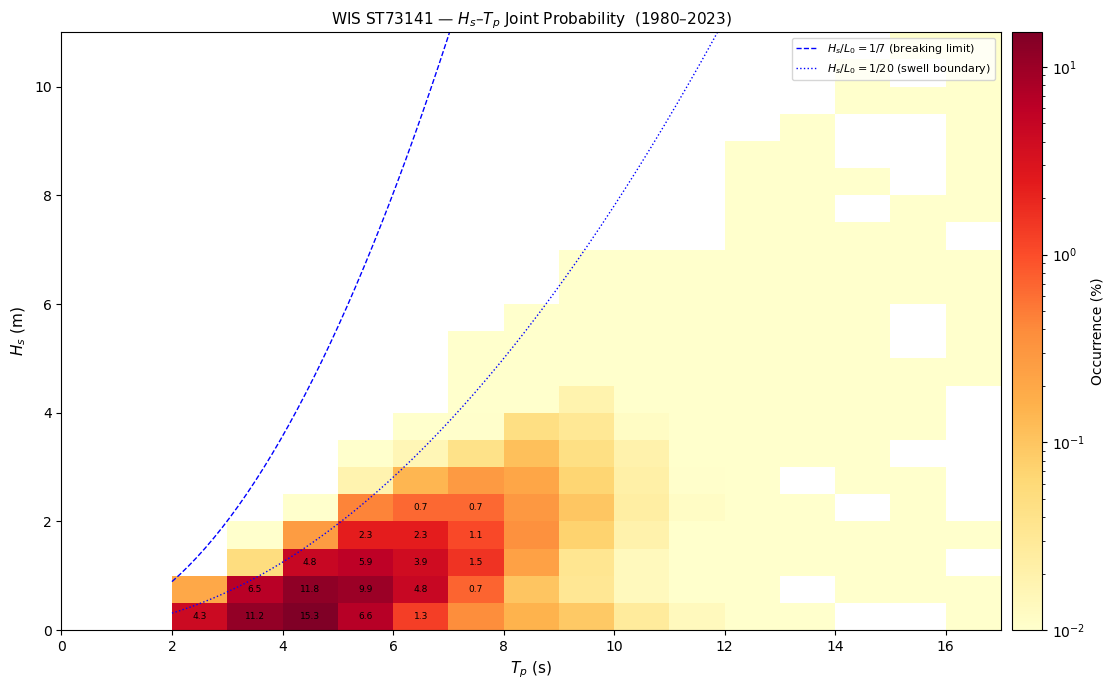

Most common bin: Hs = 0.2 m, Tp = 4.5 s  (15.3%)


In [7]:
# ==============================================================================
# CELL 7 — Hs–Tp joint probability heat map
#
# 2D histogram of occurrence frequency (% of all hours).
# Deep-water steepness limits overlaid.
# Reference: ISO 21650; USACE CEM.
# ==============================================================================

Hs_edges = np.arange(0, df['Hs'].max() + 0.5, 0.5)
Tp_edges = np.arange(0, df['Tp'].max() + 1.0, 1.0)

valid = df[['Hs','Tp']].dropna()
counts, _, _ = np.histogram2d(valid['Hs'], valid['Tp'],
                               bins=[Hs_edges, Tp_edges])
freq_pct = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(12, 7))
freq_masked = np.ma.masked_where(freq_pct == 0, freq_pct)
cmap = plt.cm.YlOrRd.copy(); cmap.set_bad('white')
im = ax.pcolormesh(Tp_edges, Hs_edges, freq_masked,
                   cmap=cmap, norm=mcolors.LogNorm(vmin=0.01, vmax=freq_pct.max()))
plt.colorbar(im, ax=ax, label='Occurrence (%)', pad=0.01)

Hs_mids = 0.5*(Hs_edges[:-1] + Hs_edges[1:])
Tp_mids = 0.5*(Tp_edges[:-1] + Tp_edges[1:])
for i, hm in enumerate(Hs_mids):
    for j, tm in enumerate(Tp_mids):
        v = freq_pct[i, j]
        if v >= 0.5:
            ax.text(tm, hm, f'{v:.1f}', ha='center', va='center',
                    fontsize=6.5, color='k')

Tp_line = np.linspace(2, Tp_edges[-1], 200)
L0_line = G * Tp_line**2 / (2*np.pi)
ax.plot(Tp_line, L0_line/7,  'b--', lw=1.0, label='$H_s/L_0 = 1/7$ (breaking limit)')
ax.plot(Tp_line, L0_line/20, 'b:',  lw=1.0, label='$H_s/L_0 = 1/20$ (swell boundary)')

ax.set_xlabel('$T_p$ (s)', fontsize=11)
ax.set_ylabel('$H_s$ (m)', fontsize=11)
ax.set_title(f'WIS ST{STATION_ID} — $H_s$–$T_p$ Joint Probability  '
             f'({FIRST_YEAR}–{LAST_YEAR})', fontsize=11)
ax.set_xlim(Tp_edges[0], Tp_edges[-1])
ax.set_ylim(Hs_edges[0], Hs_edges[-1])
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'ST{STATION_ID}_Hs_Tp_joint_prob.png', dpi=150, bbox_inches='tight')
plt.show()

imax = np.unravel_index(counts.argmax(), counts.shape)
print(f'Most common bin: Hs = {Hs_mids[imax[0]]:.1f} m, '
      f'Tp = {Tp_mids[imax[1]]:.1f} s  ({freq_pct.max():.1f}%)')

In [8]:
# ==============================================================================
# CELL 8 — Extreme value analysis: annual block maxima → GEV → return levels
#
# GEV CDF:  F(x) = exp{−[1 + ξ(x−μ)/σ]^(−1/ξ)}
#   ξ > 0 → Fréchet (heavy tail); ξ = 0 → Gumbel; ξ < 0 → Weibull (bounded)
# scipy convention: shape c = −ξ (sign opposite to Coles 2001)
# Plotting positions: Gringorten (1963), unbiased for GEV.
# 95% CI via bootstrap (500 resamples).
#
# References:
#   Coles, S. (2001). An Introduction to Statistical Modeling of Extreme
#     Values. Springer.
#   Gringorten, I.I. (1963). J. Geophys. Res. 68(3):813-814.
# ==============================================================================

return_periods = np.array([2, 5, 10, 25, 50, 100])
N_BOOT = 500

def gev_return_levels(series, label, unit):
    ann_max = series.groupby(series.index.year).max().dropna()
    n  = len(ann_max)
    c, loc, scale = spstats.genextreme.fit(ann_max)
    rl  = spstats.genextreme.isf(1/return_periods, c, loc, scale)
    ranks = ann_max.rank()
    emp_T  = (n + 0.12) / (n - ranks + 0.44)
    emp_rl = ann_max.sort_values().values
    boot = np.array([
        spstats.genextreme.isf(1/return_periods,
            *spstats.genextreme.fit(
                np.random.choice(ann_max, size=n, replace=True)))
        for _ in range(N_BOOT)])
    ci_lo = np.percentile(boot, 2.5,  axis=0)
    ci_hi = np.percentile(boot, 97.5, axis=0)
    tbl = pd.DataFrame({
        'Return period (yr)': return_periods,
        f'{label} ({unit})' : rl.round(2),
        '95% CI low'        : ci_lo.round(2),
        '95% CI high'       : ci_hi.round(2),
    })
    return tbl, ann_max, emp_T, emp_rl, (c, loc, scale)

tbl_Hs,    am_Hs,    eT_Hs,    erl_Hs,    fit_Hs    = gev_return_levels(df['Hs'],    'Hs',    'm')
tbl_Tp,    am_Tp,    eT_Tp,    erl_Tp,    fit_Tp    = gev_return_levels(df['Tp'],    'Tp',    's')
tbl_R2,    am_R2,    eT_R2,    erl_R2,    fit_R2    = gev_return_levels(df['R2'],    'R2%',   'm')
tbl_P,     am_P,     eT_P,     erl_P,     fit_P     = gev_return_levels(df['P_kW'],  'P',     'kW/m')
tbl_Omega, am_Omega, eT_Omega, erl_Omega, fit_Omega = gev_return_levels(df['Omega'], 'Omega', '-')

for lbl, tbl in [('Hs',tbl_Hs),('Tp',tbl_Tp),('R2%',tbl_R2),
                  ('P (kW/m)',tbl_P),('Omega',tbl_Omega)]:
    print(f'\n── {lbl} GEV return levels ──')
    print(tbl.to_string(index=False))


── Hs GEV return levels ──
 Return period (yr)  Hs (m)  95% CI low  95% CI high
                  2    4.17        3.75         4.66
                  5    5.94        5.05         6.94
                 10    7.60        6.07         9.40
                 25   10.49        7.72        15.41
                 50   13.40        9.23        23.75
                100   17.14       11.10        36.11

── Tp GEV return levels ──
 Return period (yr)  Tp (s)  95% CI low  95% CI high
                  2   11.55       10.73        12.59
                  5   13.62       12.70        14.58
                 10   14.89       13.96        15.66
                 25   16.39       15.16        18.20
                 50   17.43       15.83        20.72
                100   18.41       16.20        23.74

── R2% GEV return levels ──
 Return period (yr)  R2% (m)  95% CI low  95% CI high
                  2     1.09        0.99         1.24
                  5     1.56        1.30         1.85
           

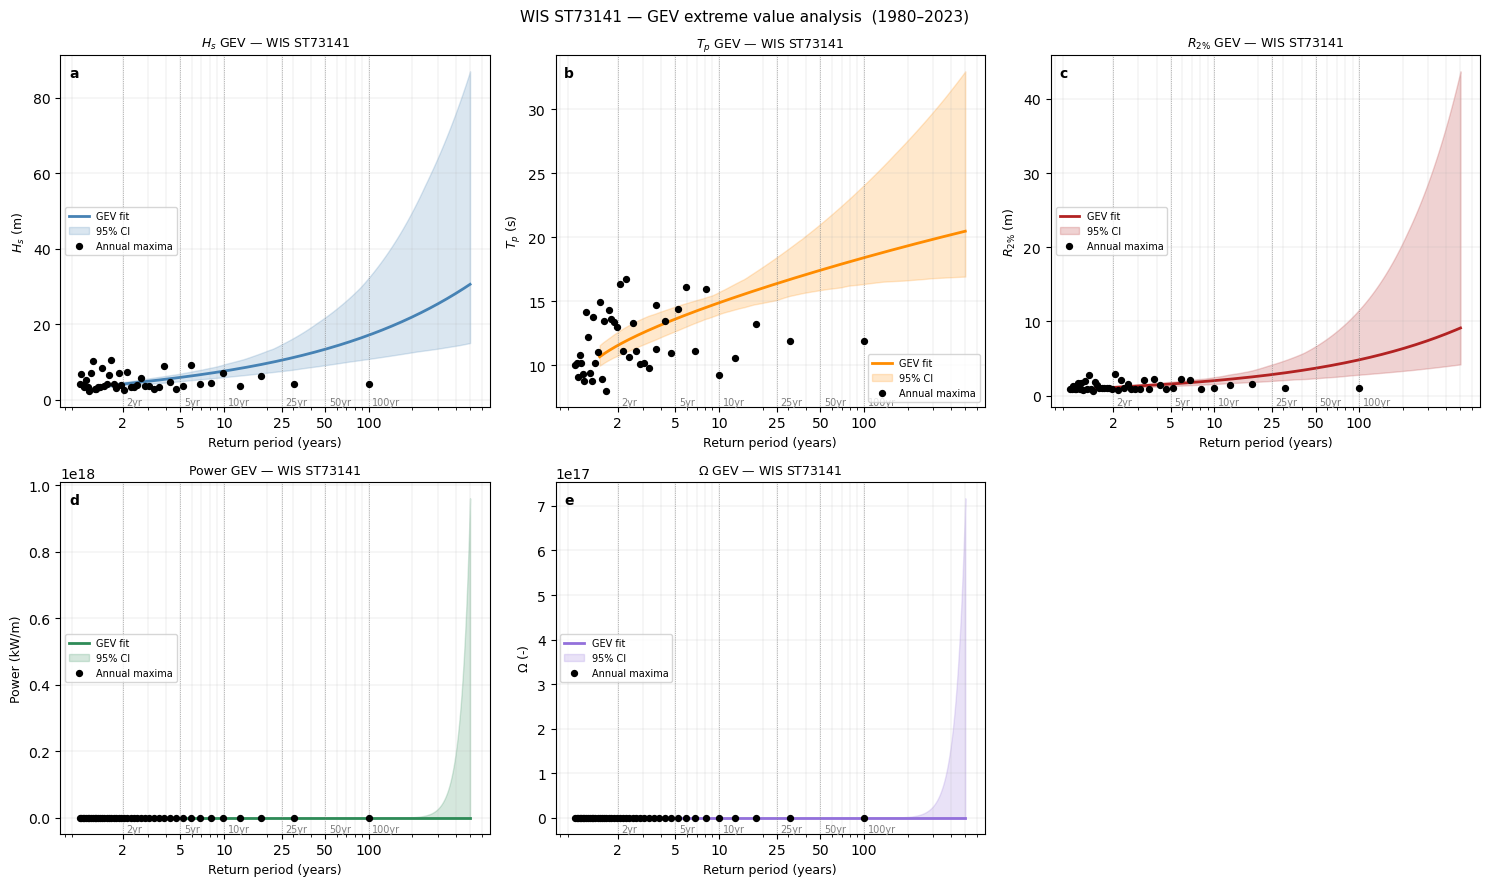

In [9]:
# ==============================================================================
# CELL 9 — GEV extreme value plots (2 × 3 panel figure)
#
# GEV fit line + 95% bootstrap CI ribbon + empirical annual maxima.
# Panels labelled a–e (f empty).
# ==============================================================================

Tp_fit = np.logspace(np.log10(1.5), np.log10(500), 300)

panel_data = [
    (tbl_Hs,    am_Hs,    eT_Hs,    erl_Hs,    fit_Hs,    '$H_s$',     'm',     'steelblue'),
    (tbl_Tp,    am_Tp,    eT_Tp,    erl_Tp,    fit_Tp,    '$T_p$',     's',     'darkorange'),
    (tbl_R2,    am_R2,    eT_R2,    erl_R2,    fit_R2,    '$R_{2\\%}$','m',     'firebrick'),
    (tbl_P,     am_P,     eT_P,     erl_P,     fit_P,     'Power',     'kW/m',  'seagreen'),
    (tbl_Omega, am_Omega, eT_Omega, erl_Omega, fit_Omega, '$\\Omega$', '-',     'mediumpurple'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
letters = 'abcde'

for ax, (tbl, am, eT, erl, fit, label, unit, col), ltr in zip(
        axes.flat, panel_data, letters):

    c, loc, scale = fit
    rl_line = spstats.genextreme.isf(1/Tp_fit, c, loc, scale)
    boot = np.array([
        spstats.genextreme.isf(1/Tp_fit,
            *spstats.genextreme.fit(
                np.random.choice(am, size=len(am), replace=True)))
        for _ in range(300)])
    ci_lo = np.percentile(boot, 2.5,  axis=0)
    ci_hi = np.percentile(boot, 97.5, axis=0)

    ax.semilogx(Tp_fit, rl_line, '-', color=col, lw=2, label='GEV fit')
    ax.fill_between(Tp_fit, ci_lo, ci_hi, alpha=0.20, color=col, label='95% CI')
    ax.scatter(eT, erl, s=18, color='k', zorder=5, label='Annual maxima')
    for rp in return_periods:
        ax.axvline(rp, color='grey', lw=0.5, ls=':')
        ax.text(rp*1.06, ax.get_ylim()[0], f'{rp}yr',
                fontsize=7, color='grey', va='bottom')
    ax.set_xlabel('Return period (years)', fontsize=9)
    ax.set_ylabel(f'{label} ({unit})', fontsize=9)
    ax.set_title(f'{label} GEV — WIS ST{STATION_ID}', fontsize=9)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_xticks([2, 5, 10, 25, 50, 100])
    ax.legend(fontsize=7); ax.grid(True, which='both', lw=0.3, alpha=0.5)
    ax.text(0.02, 0.97, ltr, transform=ax.transAxes,
            fontsize=10, fontweight='bold', va='top')

# hide unused 6th panel
axes.flat[-1].set_visible(False)

fig.suptitle(f'WIS ST{STATION_ID} — GEV extreme value analysis  '
             f'({FIRST_YEAR}–{LAST_YEAR})', fontsize=11)
plt.tight_layout()
plt.savefig(f'ST{STATION_ID}_extreme_GEV.png', dpi=150, bbox_inches='tight')
plt.show()

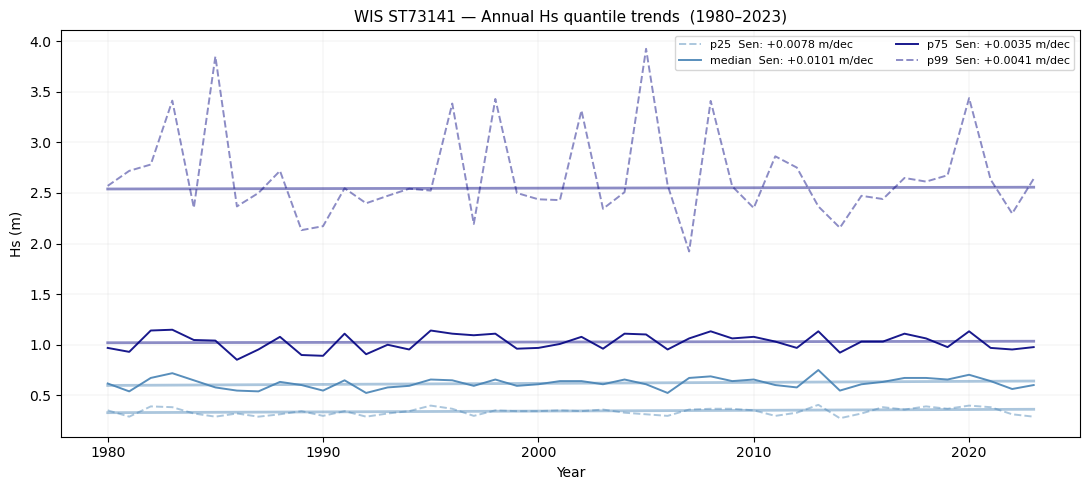

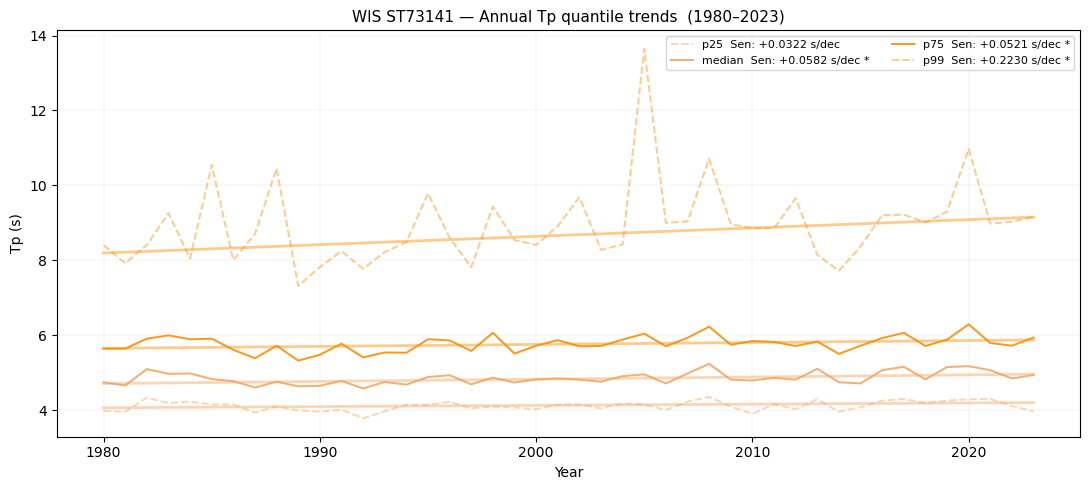

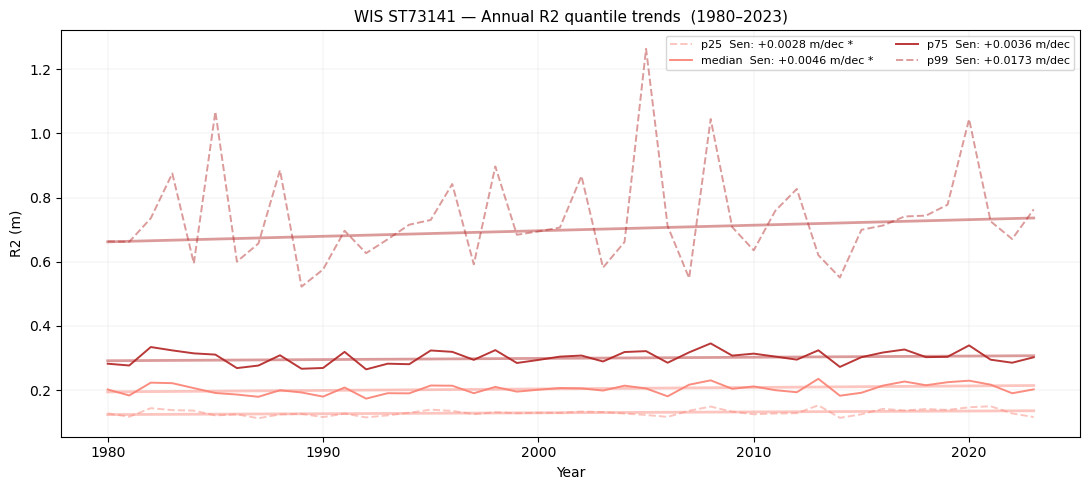

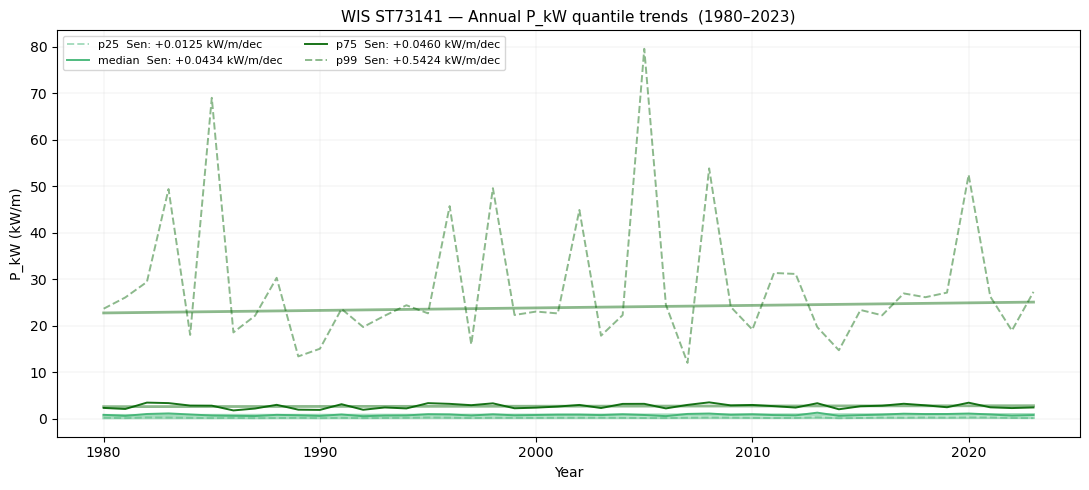

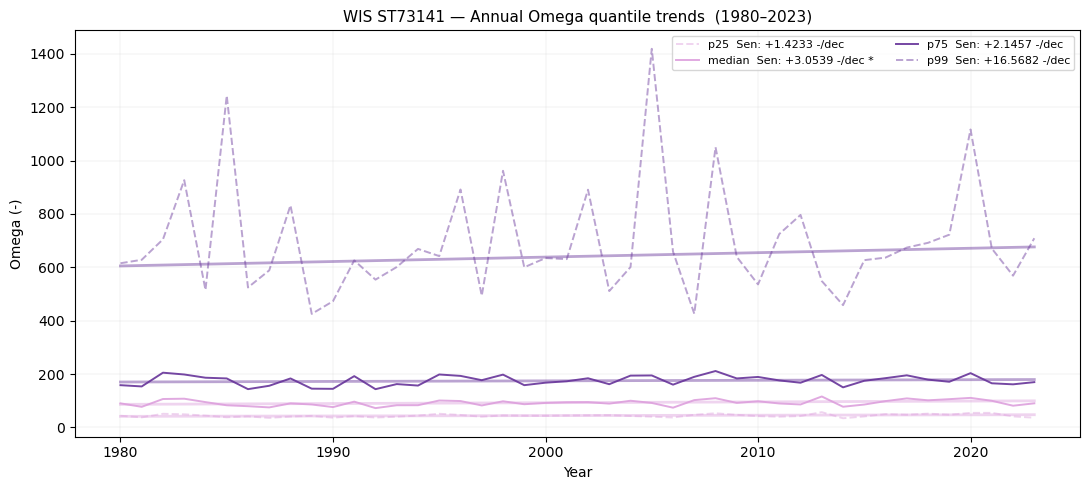

In [10]:
# ==============================================================================
# CELL 10 — Quantile trend plots (p25 / median / p75 / p99)
#
# Parallel Sen lines → bulk distributional shift.
# Diverging lines → tail changes disproportionate to bulk.
# ==============================================================================

from scipy import stats as spstats   # already imported; just ensures scope

def plot_quantile_trends(ann_df, var, unit, c_lo, c_hi, fname):
    quantiles = [
        ('p25',    '--', 0.45, c_lo, 'p25'),
        ('median', '-',  0.90, c_lo, 'median'),
        ('p75',    '-',  0.90, c_hi, 'p75'),
        ('p99',    '--', 0.45, c_hi, 'p99'),
    ]
    fig, ax = plt.subplots(figsize=(11, 5))
    for stat, ls, alpha, color, lbl in quantiles:
        key = f'{var}_{stat}'
        res = all_trends[key]
        y, yrs, mk = res['y'], res['yrs'], res['mk']
        ax.plot(yrs, y, ls=ls, color=color, alpha=alpha, lw=1.4,
                label=f'{lbl}  Sen: {mk["sen_slope"]*10:+.4f} {unit}/dec'
                      + (' *' if mk['p'] < 0.05 else ''))
        sen_y = mk['sen_intercept'] + mk['sen_slope'] * np.arange(len(yrs))
        ax.plot(yrs, sen_y, '-', color=color, lw=2.0, alpha=0.45)
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel(f'{var} ({unit})', fontsize=10)
    ax.set_title(f'WIS ST{STATION_ID} — Annual {var} quantile trends  '
                 f'({FIRST_YEAR}–{LAST_YEAR})', fontsize=11)
    ax.legend(fontsize=8, ncol=2)
    ax.grid(lw=0.3, alpha=0.4)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

plot_quantile_trends(ann_Hs,    'Hs',    'm',    'steelblue',     'navy',
                     f'ST{STATION_ID}_Hs_quantile_trends.png')
plot_quantile_trends(ann_Tp,    'Tp',    's',    'sandybrown',    'darkorange',
                     f'ST{STATION_ID}_Tp_quantile_trends.png')
plot_quantile_trends(ann_R2,    'R2',    'm',    'salmon',        'firebrick',
                     f'ST{STATION_ID}_R2_quantile_trends.png')
plot_quantile_trends(ann_P,     'P_kW',  'kW/m', 'mediumseagreen','darkgreen',
                     f'ST{STATION_ID}_P_quantile_trends.png')
plot_quantile_trends(ann_Omega, 'Omega', '-',    'plum',          'rebeccapurple',
                     f'ST{STATION_ID}_Omega_quantile_trends.png')

Early: 1980–2000  (192,863 hrs)
Late : 2002–2023  (192,840 hrs)

Hs:
  1980–2001: mean=0.743  med=0.602  p95=1.812  p99=2.641  max=8.852
  2002–2023: mean=0.763  med=0.633  p95=1.828  p99=2.641  max=10.531
  KS: stat=0.0211  p=0.0000

R2:
  1980–2001: mean=0.228  med=0.197  p95=0.487  p99=0.707  max=2.087
  2002–2023: mean=0.239  med=0.208  p95=0.508  p99=0.745  max=2.870
  KS: stat=0.0353  p=0.0000

P_kW:
  1980–2001: mean=2.643  med=0.824  p95=10.229  p99=25.722  max=470.143
  2002–2023: mean=2.994  med=0.929  p95=10.700  p99=26.558  max=811.359
  KS: stat=0.0271  p=0.0000

Omega:
  1980–2001: mean=129.800  med=88.392  p95=374.734  p99=653.632  max=3558.581
  2002–2023: mean=138.313  med=95.456  p95=389.437  p99=688.635  max=5287.962
  KS: stat=0.0301  p=0.0000


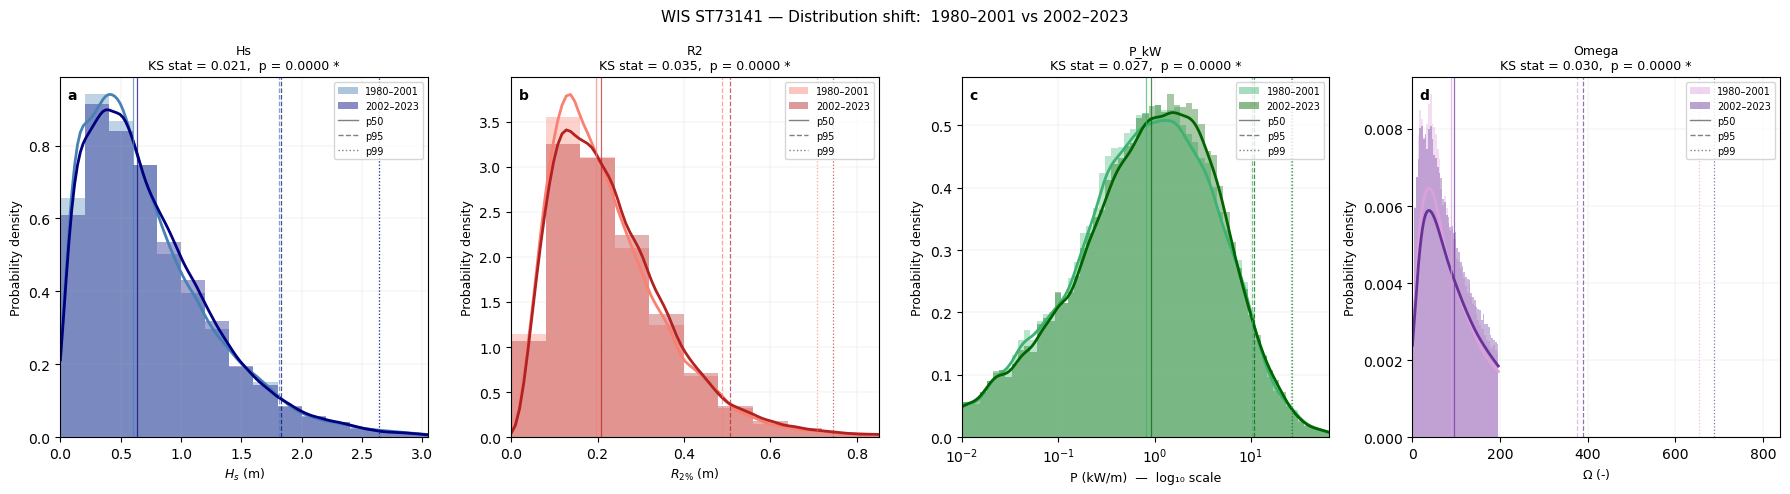

In [11]:
# ==============================================================================
# CELL 11 — Distribution shift: first 22 years vs last 22 years
#
# Two-sample Kolmogorov-Smirnov test (Massey 1951, JASA 46:68) tests whether
# the two empirical distributions share a common parent.
# Significant KS → distributional shift beyond a simple mean change.
# Wave power plotted on log10 axis to reveal the full dynamic range.
# ==============================================================================

from scipy.stats import gaussian_kde, ks_2samp
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

MID_YEAR = FIRST_YEAR + 22   # 1980+22 = 2002
early = df[df.index.year <  MID_YEAR]
late  = df[df.index.year >= MID_YEAR]
print(f'Early: {early.index.year.min()}–{early.index.year.max()-1}  '
      f'({len(early):,} hrs)')
print(f'Late : {late.index.year.min()}–{late.index.year.max()}  '
      f'({len(late):,} hrs)')

var_cfg = [
    ('Hs',    '$H_s$ (m)',        np.arange(0, 9.5, 0.20),  'steelblue',     'navy',         False),
    ('R2',    '$R_{2\\%}$ (m)',   np.arange(0, 4.0, 0.08),  'salmon',        'firebrick',    False),
    ('P_kW',  'P (kW/m)',         None,                      'mediumseagreen','darkgreen',    True),
    ('Omega', '$\\Omega$ (-)',    np.arange(0, 200, 4),      'plum',          'rebeccapurple',False),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
letters = 'abcd'

for ax, (col, xlabel, edges, c_e, c_l, log_scale), ltr in zip(axes, var_cfg, letters):
    e_v = early[col].dropna().values
    l_v = late[col].dropna().values

    hist_handles = [
        Patch(facecolor=c_e, alpha=0.45, label=f'{FIRST_YEAR}–{MID_YEAR-1}'),
        Patch(facecolor=c_l, alpha=0.45, label=f'{MID_YEAR}–{LAST_YEAR}'),
    ]

    if log_scale:
        e_log = np.log10(e_v[e_v > 0])
        l_log = np.log10(l_v[l_v > 0])
        log_edges = np.linspace(np.log10(0.01),
                    np.percentile(np.concatenate([e_log, l_log]), 99.8), 60)
        ax.hist(e_log, bins=log_edges, density=True, alpha=0.35, color=c_e)
        ax.hist(l_log, bins=log_edges, density=True, alpha=0.35, color=c_l)
        x_kde = np.linspace(log_edges[0], log_edges[-1], 400)
        ax.plot(x_kde, gaussian_kde(e_log)(x_kde), '-', color=c_e, lw=2)
        ax.plot(x_kde, gaussian_kde(l_log)(x_kde), '-', color=c_l, lw=2)
        for pct, ls in [(50,'-'),(95,'--'),(99,':')]:
            for v, c in [(e_v,c_e),(l_v,c_l)]:
                ax.axvline(np.log10(np.percentile(v,pct)), color=c, ls=ls, lw=0.9, alpha=0.7)
        tick_v = np.array([-2,-1,0,1,2])
        tick_v = tick_v[(tick_v>=log_edges[0])&(tick_v<=log_edges[-1])]
        ax.set_xticks(tick_v)
        ax.set_xticklabels([f'$10^{{{int(v)}}}$' for v in tick_v])
        ax.set_xlim(log_edges[0], log_edges[-1])
        ax.set_xlabel('P (kW/m)  —  log₁₀ scale', fontsize=9)
        ks_stat, ks_p = ks_2samp(e_log, l_log)
    else:
        ax.hist(e_v, bins=edges, density=True, alpha=0.35, color=c_e)
        ax.hist(l_v, bins=edges, density=True, alpha=0.35, color=c_l)
        x_kde = np.linspace(edges[0], edges[-1], 400)
        ax.plot(x_kde, gaussian_kde(e_v)(x_kde), '-', color=c_e, lw=2)
        ax.plot(x_kde, gaussian_kde(l_v)(x_kde), '-', color=c_l, lw=2)
        for pct, ls in [(50,'-'),(95,'--'),(99,':')]:
            for v, c in [(e_v,c_e),(l_v,c_l)]:
                ax.axvline(np.percentile(v,pct), color=c, ls=ls, lw=0.9, alpha=0.7)
        xmax = np.percentile(np.concatenate([e_v,l_v]), 99.5)
        ax.set_xlim(edges[0], xmax)
        ax.set_xlabel(xlabel, fontsize=9)
        ks_stat, ks_p = ks_2samp(e_v, l_v)

    pct_handles = [
        Line2D([0],[0], color='grey', ls='-',  lw=1, label='p50'),
        Line2D([0],[0], color='grey', ls='--', lw=1, label='p95'),
        Line2D([0],[0], color='grey', ls=':',  lw=1, label='p99'),
    ]
    ax.legend(handles=hist_handles + pct_handles, fontsize=7, loc='upper right', ncol=1)
    ax.set_ylabel('Probability density', fontsize=9)
    ax.set_title(f'{col}\nKS stat = {ks_stat:.3f},  p = {ks_p:.4f}'
                 + (' *' if ks_p < 0.05 else ''), fontsize=9)
    ax.grid(lw=0.3, alpha=0.4)
    ax.text(0.02, 0.97, ltr, transform=ax.transAxes,
            fontsize=10, fontweight='bold', va='top')

    print(f'\n{col}:')
    for lbl, v in [(f'{FIRST_YEAR}–{MID_YEAR-1}', e_v),(f'{MID_YEAR}–{LAST_YEAR}', l_v)]:
        print(f'  {lbl}: mean={v.mean():.3f}  med={np.median(v):.3f}  '
              f'p95={np.percentile(v,95):.3f}  p99={np.percentile(v,99):.3f}  '
              f'max={v.max():.3f}')
    print(f'  KS: stat={ks_stat:.4f}  p={ks_p:.4f}')

fig.suptitle(f'WIS ST{STATION_ID} — Distribution shift:  '
             f'{FIRST_YEAR}–{MID_YEAR-1} vs {MID_YEAR}–{LAST_YEAR}', fontsize=11)
plt.tight_layout()
plt.savefig(f'ST{STATION_ID}_distribution_shift.png', dpi=150, bbox_inches='tight')
plt.show()